1. Using the Data2.las dataset provided, perform a complete modelling workflow following the same approach demonstrated in the Introductory Modelling lecture notebook.
* Your goal is to build a regression model that predicts Capillary Pressure (Pc) from the other available variables in the dataset.

Evaluate the performance of the model using the following metrics:
* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* Coefficient of Determination (R²)


In [ ]:
# Install & Import all the important Libraries

!pip install scikit-learn
!pip install lasio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lasio as ls


from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report,
ConfusionMatrixDisplay)

In [ ]:
# Your modelling code starts here

# Loading the LAS File


las = ls.read ("/content/Data2.las")
df = las.df()
df.head()

,CALI,DT,GR,RESD,LLS,NPHI,RHOB
DEPT,,,,,,,
10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


In [ ]:
# the code below replaces the NULL Values

NULL_VALUE = float(las.well.NULL.value)
df.replace(NULL_VALUE, np.nan, inplace=True)

df

,CALI,DT,GR,RESD,LLS,NPHI,RHOB
DEPT,,,,,,,
10.0,19.5,NaN,0.600000,NaN,NaN,NaN,NaN
10.5,19.5,NaN,0.600000,NaN,NaN,NaN,NaN
11.0,19.5,NaN,0.600000,NaN,NaN,NaN,NaN
11.5,19.5,NaN,0.600000,NaN,NaN,NaN,NaN
12.0,19.5,NaN,0.600000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
11539.5,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN
11540.0,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN
11540.5,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN


In [ ]:
# the code below resets index i.e converts depth values into a column

df = las.df().reset_index()
df.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
1,10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
2,11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
3,11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
4,12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


In [ ]:
# then proceeds to conduct EDA

print(df.columns.tolist())

['DEPT', 'CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI', 'RHOB']


In [ ]:
df.shape

(23064, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23064 entries, 0 to 23063
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPT    23064 non-null  float64
 1   CALI    23021 non-null  float64
 2   DT      15309 non-null  float64
 3   GR      23064 non-null  float64
 4   RESD    15309 non-null  float64
 5   LLS     15309 non-null  float64
 6   NPHI    15309 non-null  float64
 7   RHOB    15181 non-null  float64
dtypes: float64(8)
memory usage: 1.4 MB


In [ ]:
df.describe().round(2)

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
count,23064.00,23021.00,15309.00,23064.00,15309.00,15309.00,15309.00,15181.00
mean,5775.75,16.74,114.79,42.33,30.64,5.78,0.23,2.18
std,3329.07,3.85,26.25,26.90,50.86,12.71,0.96,0.15
min,10.00,5.72,13.90,0.60,0.05,0.09,-9.99,1.27
25%,2892.88,12.73,97.90,19.36,1.74,1.80,0.27,2.14
50%,5775.75,17.20,110.60,37.42,5.52,3.53,0.32,2.20
75%,8658.62,19.80,121.40,55.59,44.51,6.46,0.37,2.25
max,11541.50,22.78,260.70,142.20,1213.06,341.10,0.63,2.67


In [ ]:
df.isna().sum()

,0
DEPT,0
CALI,43
DT,7755
GR,0
RESD,7755
LLS,7755
NPHI,7755
RHOB,7883


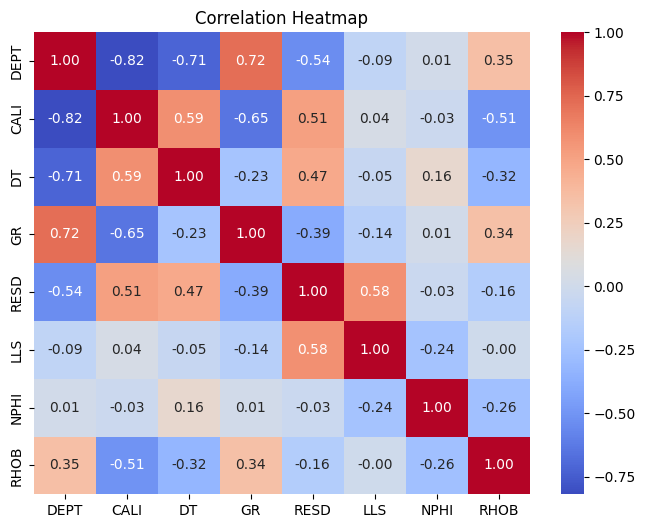

In [ ]:
# Correlation heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# the code below removes "out of range values"

ranges = {
    'CALI': (6, 20),
    'DT':   (40, 240),
    'GR':   (0, 150),
    'RESD': (0.2, 2000),
    'LLS':  (0.2, 2000),
    'NPHI': (-0.15, 0.45),
    'RHOB': (1.95, 2.95),
}

df_clean = df.copy()

for col, (lo, hi) in ranges.items():
    if col in df_clean.columns:
        mask = df_clean[col].notna() & ((df_clean[col] < lo) | (df_clean[col] > hi))
        print(col, 'Out-of-range count:', int(mask.sum()))
        df_clean.loc[mask, col] = np.nan

CALI Out-of-range count: 5415
DT Out-of-range count: 35
GR Out-of-range count: 0
RESD Out-of-range count: 82
LLS Out-of-range count: 76
NPHI Out-of-range count: 1239
RHOB Out-of-range count: 773


In [ ]:
# Before cleaning
df.isna().sum()

,0
DEPT,0
CALI,43
DT,7755
GR,0
RESD,7755
LLS,7755
NPHI,7755
RHOB,7883


In [ ]:
# After cleaning
df_clean.isna().sum()

,0
DEPT,0
CALI,5458
DT,7790
GR,0
RESD,7837
LLS,7831
NPHI,8994
RHOB,8656


In [ ]:
# next we state out the target and feature
# in this case, the target being RHOB due to the absence of Pc values in the dataset

target    = 'RHOB'
features  = ['CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI']
depth_col = 'DEPT'

model_df = df_clean[features + [target, depth_col]].copy()
reg_df   = model_df.dropna(subset=features + [target]).copy()

print('Full model_df shape:', model_df.shape)
print('Clean reg_df shape: ', reg_df.shape)

Full model_df shape: (23064, 8)
Clean reg_df shape:  (12820, 8)


In [ ]:
reg_df.head()

,CALI,DT,GR,RESD,LLS,NPHI,RHOB,DEPT
7964,19.15,57.399998,23.571100,1.3630,2.3469,0.3883,2.0429,3992.0
7965,19.10,67.599998,25.473600,0.8341,1.9242,0.4387,2.0511,3992.5
7974,19.50,162.699997,35.584202,0.2101,0.6135,0.3250,2.1017,3997.0
7975,19.60,163.000000,36.689899,60.5200,3.9638,0.2839,2.1919,3997.5
7976,19.35,164.700012,37.687599,60.5200,2.0985,0.2784,2.1709,3998.0


In [ ]:
X = reg_df[features]
y = reg_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('REG data:   ', reg_df.shape)
print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)

REG data:    (12820, 8)
Train shape: (10256, 6)
Test shape:  (2564, 6)


In [ ]:
lin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
print('Model trained successfully!')

Model trained successfully!


In [ ]:
mae  = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2   = r2_score(y_test, y_pred_lin)

print(f'MAE:  {mae:.4f} g/cc')
print(f'RMSE: {rmse:.4f} g/cc')
print(f'R²:   {r2:.4f}')

MAE:  0.0477 g/cc
RMSE: 0.0626 g/cc
R²:   0.4464


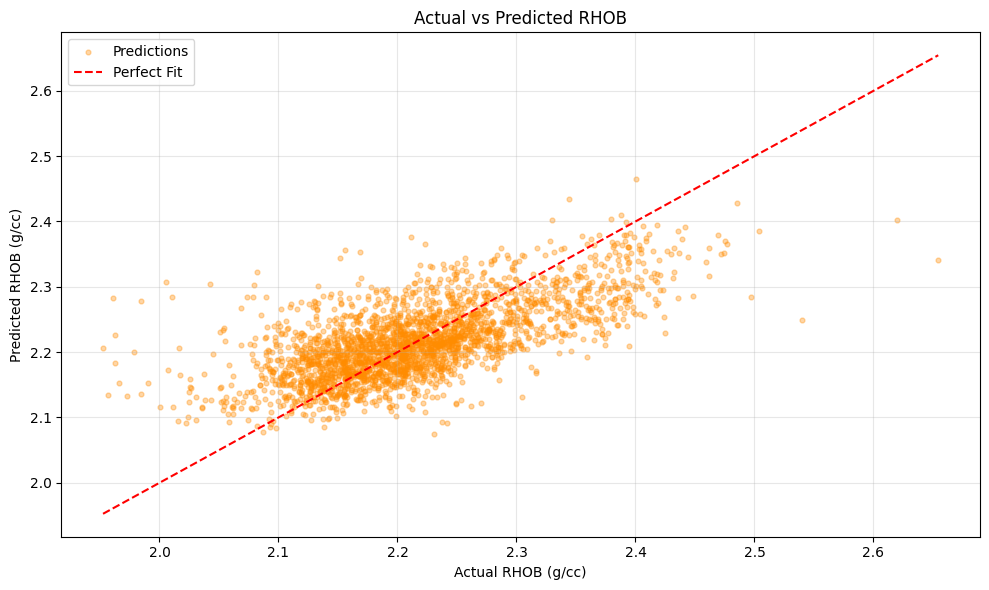

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Actual vs Predicted plot
ax.scatter(y_test, y_pred_lin, alpha=0.35, color='darkorange', s=12, label='Predictions')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=1.5, label='Perfect Fit')

ax.set_xlabel('Actual RHOB (g/cc)')
ax.set_ylabel('Predicted RHOB (g/cc)')
ax.set_title('Actual vs Predicted RHOB')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
lr           = lin_model.named_steps['model']
intercept    = lr.intercept_
coefficients = lr.coef_
feat_names   = X_train.columns

equation = f'RHOB = {intercept:.4f}'
for coef, feat in zip(coefficients, feat_names):
    equation += f' + ({coef:.4f} * {feat})'

print(equation)

RHOB = 2.2175 + (0.0097 * CALI) + (-0.0153 * DT) + (0.0634 * GR) + (0.0269 * RESD) + (-0.0189 * LLS) + (-0.0427 * NPHI)


In [ ]:
# Find rows where RHOB is missing but all 6 features (CALI, DT, GR, RESD, LLS, NPHI) are available
missing_target = model_df[model_df[target].isna()].copy()
missing_target = missing_target.dropna(subset=features)

print(f'Rows with missing RHOB but all features present: {missing_target.shape[0]}')

Rows with missing RHOB but all features present: 141


In [ ]:
missing_target.head()

,CALI,DT,GR,RESD,LLS,NPHI,RHOB,DEPT
7866,19.549999,47.700001,24.705299,60.5200,55.947300,0.4229,NaN,3943.0
7867,19.100000,46.800003,22.558100,60.5200,58.741402,0.4179,NaN,3943.5
7868,18.650000,56.099998,24.000000,58.6483,48.180302,0.4279,NaN,3944.0
7872,18.250000,57.000000,32.725700,60.5200,52.570000,0.4370,NaN,3946.0
7873,18.250000,53.900002,28.309000,60.5200,78.695000,0.4314,NaN,3946.5


In [ ]:
# Predict RHOB for all 141 missing rows
row         = missing_target[missing_target[depth_col] == missing_target.iloc[0][depth_col]][features]
pred_single = lin_model.predict(row)
print(f'Predicted RHOB at depth {missing_target.iloc[0][depth_col]} ft: {pred_single[0]:.4f} g/cc')

Predicted RHOB at depth 3943.0 ft: 2.0652 g/cc


In [ ]:
# Predict all 141 missing rows at once
all_preds = lin_model.predict(missing_target[features])
missing_target = missing_target.copy()
missing_target['Predicted_RHOB'] = all_preds.round(4)

print('Sample of predictions:')
print(missing_target[[depth_col, 'Predicted_RHOB']].head(10).to_string())

Sample of predictions:
        DEPT  Predicted_RHOB
7866  3943.0          2.0652
7867  3943.5          2.0577
7868  3944.0          2.0603
7872  3946.0          2.0696
7873  3946.5          2.0250
7874  3947.0          2.0559
7875  3947.5          1.9435
7876  3948.0          2.0708
7878  3949.0          2.0850
7879  3949.5          2.0616


2. Display your 3 log tracks (GR, RES, NPHI/RHOB) using the IPYWIDGET as demonstrated in the Sunday class and make it interactive.

In [ ]:
# Your Visualization code goes here

import ipywidgets as widgets
from IPython.display import display

min_depth = int(df['DEPT'].min())
max_depth = int(df['DEPT'].max())


def plot_triple_combo_logs(depth_range):
    d_min, d_max = depth_range
    df_plot = df[(df['DEPT'] >= d_min) & (df['DEPT'] <= d_max)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 10), sharey=True)


    # GR Log
    axes[0].plot(df_plot['GR'], df_plot['DEPT'], color='green', lw=0.8)
    axes[0].fill_betweenx(df_plot['DEPT'], df_plot['GR'], 0, alpha=0.15, color='green')
    axes[0].set_xlabel('GR (API)'); axes[0].set_ylabel('Depth (ft)')
    axes[0].set_title('Gamma Ray (GR)'); axes[0].set_xlim(0, 150)
    axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3)

    # RESD / LLS Plot
    axes[1].semilogx(df_plot['RESD'], df_plot['DEPT'], color='red',  lw=0.8, label='RESD')
    axes[1].semilogx(df_plot['LLS'],  df_plot['DEPT'], color='blue', lw=0.8, ls='--', label='LLS')
    axes[1].set_xlabel('Resistivity (ohm.m)')
    axes[1].set_title('Resistivity (RESD / LLS)')
    axes[1].invert_yaxis(); axes[1].grid(True, alpha=0.3, which='both')
    axes[1].legend(fontsize=8)

    # NPHI / RHOB Cross plot
    ax3 = axes[2]; ax3b = ax3.twiny()
    ax3.plot(df_plot['NPHI'],  df_plot['DEPT'], color='blue', lw=0.8, label='NPHI')
    ax3b.plot(df_plot['RHOB'], df_plot['DEPT'], color='red',  lw=0.8, label='RHOB')
    ax3.set_xlabel('NPHI (v/v)', color='blue')
    ax3b.set_xlabel('RHOB (g/cc)', color='red')
    ax3.set_title('Porosity (NPHI / RHOB)')
    ax3.set_xlim(0.45, -0.15)     # reversed — standard petrophysics convention
    ax3b.set_xlim(1.95, 2.95)
    ax3.invert_yaxis(); ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', colors='blue')
    ax3b.tick_params(axis='x', colors='red')

    plt.tight_layout(); plt.show()

# the code below displays the interactive widget
out = widgets.interactive_output(plot_logs, {'depth_range': depth_slider})
display(depth_slider, out)

IntRangeSlider(value=(3990, 6000), description='Depth (ft):', layout=Layout(width='650px'), max=11541, min=10,…

Output()


3. Conclude the assignment with a brief discussion explaining:
* The most important predictors of capillary pressure in the dataset
* The overall performance of the regression model
* Whether the model could be improved with additional variables or modelling techniques.

# (1) The most predictors of Density according to the dataset is contained in the regression equation (RHOB = 2.2175 + (0.0097 * CALI) + (-0.0153 * DT) + (0.0634 * GR) + (0.0269 * RESD) + (-0.0189 * LLS) + (-0.0427 * NPHI)) is GR, on the positive side and NPHI on the negative side. This shows that the higher the GR value (higher clay mineral content), the higher the RHOB and likewise, the lower the NPHI value, the higher the RHOB and vice versa. So Lithology Log and Porosity Log are the most important predictors of Density according to the dataset. This is consistent with known natural laws.

# Note: The target in this case is RHOB since Pc column wasn't part of the dataset.


# (2) MAE:  0.0477 g/cc, RMSE: 0.0626 g/cc, R²:   0.4464. On average, my predictions are off by 0.0477 g/cc, The model correctly explains about 45% of what makes RHOB vary from depth to depth.